<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

## Descripción del proyecto

Se trabajará con información de Zuber, una nueva empresa de viajes compartidos que se está lanzando en Chicago. 

El objetivo es encontrar patrones con la información disponible; para comprender las preferencias de los pasajeros y el impacto de los factores externos (climatológicos) en los viajes.

Por último se probará una hipótesis sobre el impacto del clima en la frecuencia de los viajes.


### Descripción de los datos

Tabla Trips contine los siguientes datos:
* company_name: nombre de la empresa de trips
* trips_amount: el número de viajes de cada compañía de trips el 15 y 16 de noviembre de 2017

Tabla end_trips contine los siguiente datos:
* dropoff_location_name: barrios de Chicago donde finalizaron los viajes
* average_trips: el promedio de viajes que terminaron en cada barrio en noviembre de 2017.

Tabla clima contine los siguientes datos:
* start_ts: fecha y hora de la recogida
* weather_conditions: condiciones climáticas en el momento en el que comenzó el viaje
* duration_seconds: duración del viaje en segundos

# 1. Inicialización ###

In [1]:
# Cargar librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [2]:
# Cargar datos

trips = pd.read_csv('/datasets/project_sql_result_01.csv')
end_trips = pd.read_csv('/datasets/project_sql_result_04.csv')
clima = pd.read_csv('/datasets/project_sql_result_07.csv')

### Limpieza de datos ###
Validar que no existan valores ausentes, duplicados y el tipo de datos este correcto para los DF trips, end_trips y clima

In [3]:
trips.info()
print(f"Datos duplicados: {trips.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
Datos duplicados: 0


In [4]:
trips.head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [5]:
end_trips.info()
print(f"Datos duplicados: {end_trips.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
Datos duplicados: 0


In [6]:
end_trips.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [7]:
clima.info()
print(f"Datos duplicados: {clima.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
Datos duplicados: 197


In [8]:
# Convertir start_ts a datetime
clima['start_ts'] = pd.to_datetime(clima['start_ts'])
print(clima.dtypes)

start_ts              datetime64[ns]
weather_conditions            object
duration_seconds             float64
dtype: object


Observaciones:

Se realiza un info() para tener un panorama general de los datos para los DataFrames.
* Trips: 64 valores, sin valores ausentes y duplicados | tipo de datos correcto para sus valores correspondientes
* end_trips: 94 valores, sin valores ausentes y duplicados | tipo de datos correcto para sus valores correspondientes.
* Clima: 1068 valores, sin valores ausentes | se cambia el tipo de datos a datetime64[ns] de start_ts

# 2. Análisis #

* Identificar los 10 principales barrios en términos de finalización del recorrido

In [9]:
finalizaciones_top_10 = end_trips.sort_values('average_trips', ascending=False).head(10)
print(finalizaciones_top_10)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


* Visualizar en gráficos: empresas de taxis y número de viajes, los 10 barrios principales por número de finalizaciones

In [10]:
top_10_empresas = trips.sort_values('trips_amount', ascending=False).head(10)
print(top_10_empresas)

                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                  Medallion Leasing         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953


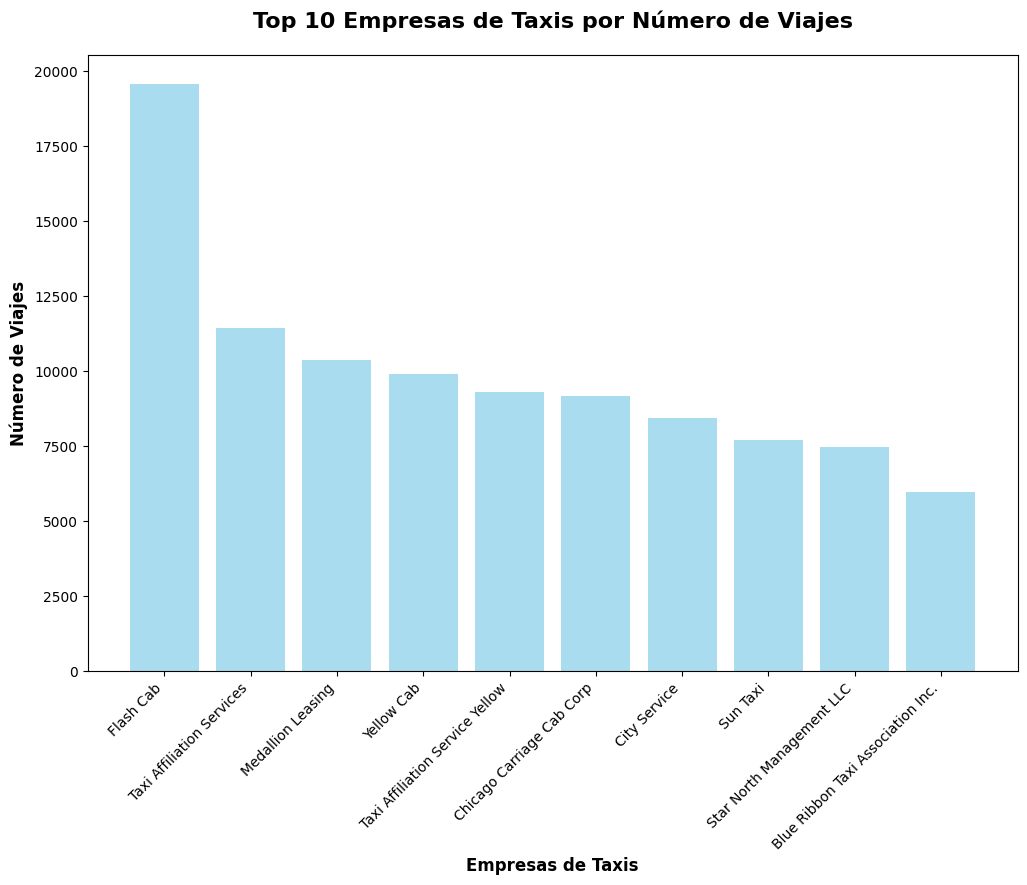

In [11]:
# Creación de gráfico de barras de las empresas y el número de viajes

plt.figure(figsize=(12, 8))
plt.bar(range(len(top_10_empresas)),
        top_10_empresas['trips_amount'],
        color='skyblue',
        alpha=0.7)
plt.title('Top 10 Empresas de Taxis por Número de Viajes', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Empresas de Taxis', fontsize=12, fontweight='bold')
plt.ylabel('Número de Viajes', fontsize=12, fontweight='bold')
plt.xticks(range(len(top_10_empresas)),
          top_10_empresas['company_name'],
          rotation=45, ha='right')
plt.show()

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Correcto!<br/>

Buena manera de mostrar el resultado, se puede observar la compañía que tiene más viajes agendados gracias a que limitaste el número de elementos que se muestran, el tamaño de la gráfica me parece el ideal para interpretar la información
</div>

Observaciones:

La empresa Flash Cab sin duda es la favorita por los usuarios, teniendo el mayor número de viajes.
En segundo lugar y con una gran diferencia entre flash cab, se encuentra Taxi Affiliation Service, en tercer lugar sin haber gran diferencia del 2do lugar se encuentra Medallion Leasing.
Por otro lado 4. Yellow Cab tiene casi la mitad del número de viajes que Flash Cab.

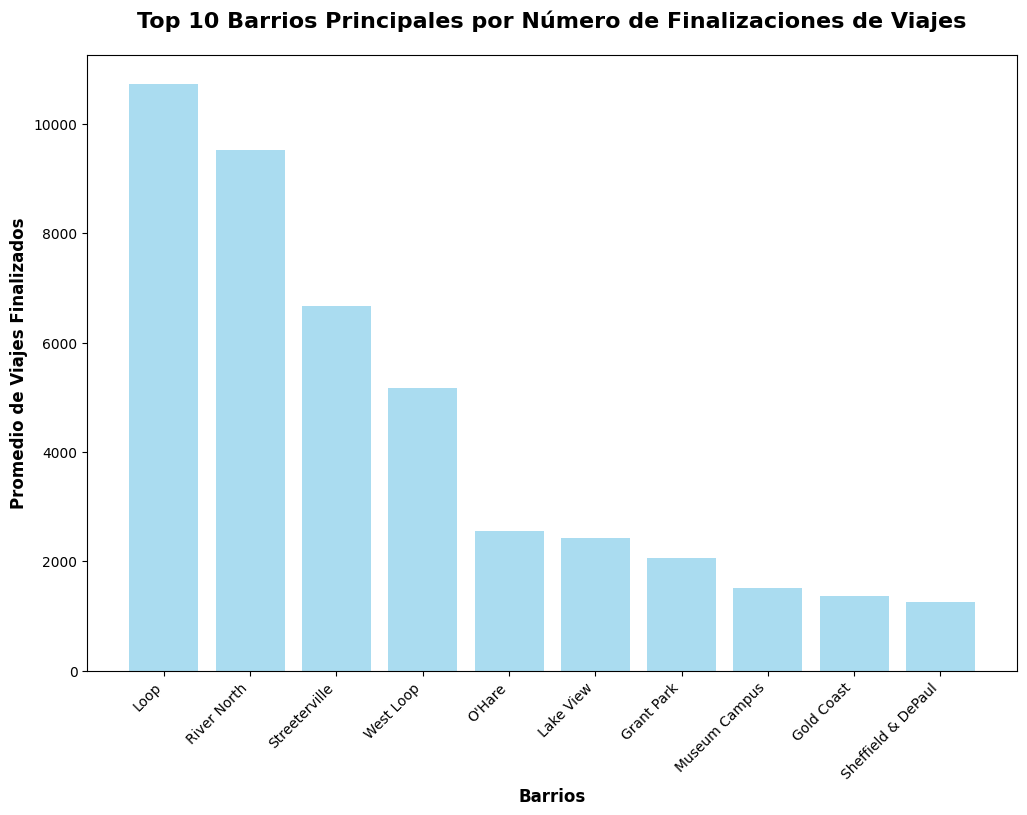

In [12]:
# Creación de gráfico de barras de los 10 barrios principales por número de finalizaciones

plt.figure(figsize=(12, 8))
plt.bar(range(len(finalizaciones_top_10)),
        finalizaciones_top_10['average_trips'],
        color='skyblue',
        alpha=0.7)
plt.title('Top 10 Barrios Principales por Número de Finalizaciones de Viajes', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Barrios', fontsize=12, fontweight='bold')
plt.ylabel('Promedio de Viajes Finalizados', fontsize=12, fontweight='bold')
plt.xticks(range(len(finalizaciones_top_10)),
          finalizaciones_top_10['dropoff_location_name'],
          rotation=45, ha='right')
plt.show()

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Correcto!<br/>

Buena manera de crear una grafica que nos muestra los lugares más frecuentados
</div>

Podemos observar que la mayoría de los barrios a los que suele ir el usuario es 
1. Loop
2. River North
3. Streeterville
4. West Loop

O'Hare, Lake View, Gran Park, Museum Campus, Gold Coast, Sheffield & DePaul, se encuentran dentro del top 10 pero no de los primeros lugares a donde suele ir el usuario.

# 3. Prueba de Hipótesis

H₀: La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare NO cambia los sábados lluviosos

H₁: La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare SÍ cambia los sábados lluviosos

Nivel de significancia (alpha): 0.05


### Criterio de prueba estadística

Se usará la prueba de t de Student para muestras independientes.
¿Por qué?
1. Comparamos medidas de dos grupos independientes.
2. Existe una variable continua que es la duración en segundos.
3. Grupos independientes: sábados lluviosos VS no lluviosos

In [13]:
# Crear columna day_of_week para incorporar el día de la semana. 
# Validar valores únicos

clima['day_of_week'] = clima['start_ts'].dt.dayofweek
print('Día de la semana:', clima['day_of_week'].unique())

Día de la semana: [5]


In [14]:
# Separar en 2 grupos según las condiciones climáticas

grupo_lluvioso = clima[clima['weather_conditions'] == 'Bad']['duration_seconds']
grupo_no_lluvioso = clima[clima['weather_conditions'] == 'Good']['duration_seconds']

print(f'Viajes en sábados NO lluviosos: {len(grupo_no_lluvioso)}')
print(f'Viajes en sábados lluviosos: {len(grupo_lluvioso)}')
print(f'Total de viajes: {len(clima)}')

Viajes en sábados NO lluviosos: 888
Viajes en sábados lluviosos: 180
Total de viajes: 1068


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Bien hecho!<b/>

La manera de separar la información de ambos días es correcta
</div>

In [15]:
# Estadística descriptivas de cada grupo

print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(f"\nGrupo NO lluvioso:")
print(f"  Media: {grupo_no_lluvioso.mean():.2f} segundos")
print(f"  Desviación estándar: {grupo_no_lluvioso.std():.2f} segundos")
print(f"  Mediana: {grupo_no_lluvioso.median():.2f} segundos")

print(f"\nGrupo lluvioso:")
print(f"  Media: {grupo_lluvioso.mean():.2f} segundos")
print(f"  Desviación estándar: {grupo_lluvioso.std():.2f} segundos")
print(f"  Mediana: {grupo_lluvioso.median():.2f} segundos")


=== ESTADÍSTICAS DESCRIPTIVAS ===

Grupo NO lluvioso:
  Media: 1999.68 segundos
  Desviación estándar: 759.20 segundos
  Mediana: 1800.00 segundos

Grupo lluvioso:
  Media: 2427.21 segundos
  Desviación estándar: 721.31 segundos
  Mediana: 2540.00 segundos


In [16]:
# Realizar la prueba t para muestras independientes
t_stat, p_value = stats.ttest_ind(grupo_no_lluvioso, grupo_lluvioso)
# Nivel de significancia
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusión: p-value ({p_value:.6f}) < α ({alpha})")
    print("Rechazamos H₀: Existe evidencia estadística de que el tiempo promedio de los viajes desde el Loop hasta el Aeropuerto cambian los sábados lluviosos")
else:
    print(f"\nConclusión: p-value ({p_value:.6f}) >= α ({alpha})")
    print("No rechazamos H₀: No hay evidencia suficiente de que el tiempo promedio de los viajes cambia cuando llueve")
print()
print("===RESULTADOS DE LA PRUEBA T===")
print(f'Estadístico t: {t_stat:4f}')
print(f'Valor p: {p_value:.6f}')
print(f'Nivel de significación (α): {alpha}"')


Conclusión: p-value (0.000000) < α (0.05)
Rechazamos H₀: Existe evidencia estadística de que el tiempo promedio de los viajes desde el Loop hasta el Aeropuerto cambian los sábados lluviosos

===RESULTADOS DE LA PRUEBA T===
Estadístico t: -6.946178
Valor p: 0.000000
Nivel de significación (α): 0.05"


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Bien hecho!<br/>

Es correcto rechazar la hipotesis nula, debido a que sí hay notables cambios entre un día de buenas condiciones y uno con malas condiciones
</div>

### Conclusiones:

* Se realizó una prueba t de Student para comparar los tiempos entre días lluviosos y no lluviosos.
* Los resultados muestran una diferencia estadísticamente significativa entre ambos grupos (t = -6.95, p < 0.05).
* En promedio, los tiempos en días lluviosos son aproximadamente 7 minutos mayores que en días no lluviosos.
* Por lo tanto, se concluye que la lluvia tiene un efecto significativo en el aumento del tiempo.

### Conclusiones generales

De acuerdo al análisis podemos visualizar que las preferencias de los pasajeros para viajar, se concentra con la empresa Flash Cab y los principales barrios a los que acuden es Loop, River North y Streeterville. 
Podemos visualizar que la duración promedio de los viajes aumentan aproximadamente 7 minutos en sábados lluviosos

# Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, los procedimientos realizados son correctos, este es un ejercicio que nos ayuda a entender y comprobar las hipotesis con procesos estadisticos.<br/>    
<br/>    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen buenas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado
- El proyecto es directo y conciso
    
</div> 